In [ ]:
# pip install seaborn --quiet
# !pip install xgboost --quiet
# !pip install lightgbm --quiet
# !pip install joblib --quiet


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import load_model
import os

# Cấu hình hiển thị
%matplotlib inline
sns.set(style="whitegrid") # Giao diện biểu đồ đẹp hơn

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv"
SCALER_FILE = "../../model/scaler.pkl" 
WINDOW_SIZE = 60
TARGET_COL = "Gold"

print(f"✅ Đã import thư viện. Tensorflow: {tf.__version__}")

✅ Đã import thư viện. Tensorflow: 2.20.0


In [4]:
print("🔄 Đang chuẩn bị dữ liệu thi đấu...")

# 1. Load Data & Scaler
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không tìm thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    if 'Datetime' in df.columns: df = df.drop(columns=['Datetime'])
    scaler = joblib.load(SCALER_FILE)
    data_values = df.values

    # 2. Chia tập Test (20% cuối)
    split_idx = int(len(data_values) * 0.8)

    # --- A. Dữ liệu cho LSTM (3D) ---
    def create_sequences(data, window_size):
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i : i + window_size])
            y.append(data[i + window_size, 0]) # Cột 0 là Gold
        return np.array(X), np.array(y)

    X_lstm, y_lstm = create_sequences(data_values, WINDOW_SIZE)
    
    # Lấy phần Test của LSTM (Đây là mốc chuẩn)
    X_test_lstm = X_lstm[split_idx:]
    y_test_target = y_lstm[split_idx:] # Đáp án đúng
    
    test_len = len(y_test_target) # Số lượng câu hỏi thi
    
    # --- B. Dữ liệu cho ML (2D) ---
    # Tạo dataset kiểu ML (Dòng t dự báo t+1)
    df_ml = df.copy()
    df_ml['Target'] = df_ml[TARGET_COL].shift(-1)
    df_ml.dropna(inplace=True)
    
    X_ml = df_ml.drop(columns=['Target']).values
    
    # Cắt lấy đúng số lượng mẫu cuối cùng bằng với LSTM để so sánh 1-1
    X_test_ml = X_ml[-test_len:]
    
    print(f"✅ Đã chuẩn bị xong đề thi!")
    print(f"   - Số lượng mẫu kiểm tra: {test_len}")
    print(f"   - Shape LSTM Test: {X_test_lstm.shape}")
    print(f"   - Shape ML Test:   {X_test_ml.shape}")

🔄 Đang chuẩn bị dữ liệu thi đấu...
✅ Đã chuẩn bị xong đề thi!
   - Số lượng mẫu kiểm tra: 1468
   - Shape LSTM Test: (1468, 60, 11)
   - Shape ML Test:   (1468, 11)


In [16]:
models = {}

print("📥 Đang load các model...")

# 1. Linear Regression
if os.path.exists("../../model/linear_model.pkl"):
    models['Linear Reg'] = joblib.load("../../model/linear_model.pkl")
    print("   - Đã load Linear Regression")

# 2. Random Forest
if os.path.exists("../../model/rf_model.pkl"):
    models['Random Forest'] = joblib.load("../../model/rf_model.pkl")
    print("   - Đã load Random Forest")

# 3. XGBoost
if os.path.exists("../../model/xgboost_model.pkl"):
    models['XGBoost'] = joblib.load("../../model/xgboost_model.pkl")
    print("   - Đã load XGBoost")

# 4. LightGBM
if os.path.exists("../../model/lgbm_model.pkl"):
    models['LightGBM'] = joblib.load("../../model/lgbm_model.pkl")
    print("   - Đã load LightGBM")

# 5. LSTM
if os.path.exists("../../model/best_model_gold_only.keras"):
    models['LSTM'] = load_model("../../model/best_model_gold_only.keras")
    print("   - Đã load LSTM")
    
if len(models) == 0:
    print("⚠️ Cảnh báo: Không tìm thấy model nào cả. Hãy train trước đi nhé!")

📥 Đang load các model...
   - Đã load Linear Regression
   - Đã load Random Forest
   - Đã load XGBoost
   - Đã load LightGBM


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickl

   - Đã load LSTM


In [18]:
results = {}
preds_usd = {} 

# Hàm Inverse Transform (Quy đổi từ 0.5 -> 2000 USD)
dummy_matrix = np.zeros((1, data_values.shape[1])) 

def inverse_price(scaled_price):
    mat = dummy_matrix.copy()
    mat[0, 0] = scaled_price # Giả sử cột 0 là Gold
    return scaler.inverse_transform(mat)[0, 0]

# 1. Chuyển ĐÁP ÁN ĐÚNG về USD
y_true_usd = np.array([inverse_price(y) for y in y_test_target])

print("🚀 Bắt đầu chấm điểm...")

for name, model in models.items():
    # A. Dự báo (Prediction)
    if name == 'LSTM':
        # --- SỬA LỖI Ở ĐÂY ---
        # Kiểm tra xem Model cần mấy cột (Feature)?
        expected_features = model.input_shape[-1] # Lấy số chiều cuối cùng (thường là 1 hoặc 11)
        
        if expected_features == 1 and X_test_lstm.shape[2] > 1:
            # Nếu model chỉ cần 1 cột mà dữ liệu có 11 cột -> Cắt lấy cột đầu tiên (Gold)
            X_input = X_test_lstm[:, :, 0:1] 
        else:
            X_input = X_test_lstm
            
        pred = model.predict(X_input, verbose=0)
        pred = pred.flatten()
    else:
        # Với các model ML (Linear, XGB...), ta cũng cần check
        # Nếu model ML train trên nhiều biến, thì giữ nguyên X_test_ml
        # Nhưng thường ML tự xử lý được hoặc báo lỗi khác, tạm thời giữ nguyên
        pred = model.predict(X_test_ml)
        
    # B. Quy đổi về USD
    pred_real = np.array([inverse_price(p) for p in pred])
    preds_usd[name] = pred_real
    
    # C. Tính điểm (Metrics)
    rmse = np.sqrt(mean_squared_error(y_true_usd, pred_real))
    mae = mean_absolute_error(y_true_usd, pred_real)
    r2 = r2_score(y_true_usd, pred_real)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"   Done: {name} (RMSE = {rmse:.2f})")

# Tạo bảng kết quả
results_df = pd.DataFrame(results).T.sort_values(by='RMSE')
print("\n🏆 BẢNG XẾP HẠNG (RMSE thấp nhất là quán quân):")
display(results_df)

🚀 Bắt đầu chấm điểm...


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


   Done: Linear Reg (RMSE = 13.26)


c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished


   Done: Random Forest (RMSE = 288.10)
   Done: XGBoost (RMSE = 309.33)
   Done: LightGBM (RMSE = 297.28)
   Done: LSTM (RMSE = 25.29)

🏆 BẢNG XẾP HẠNG (RMSE thấp nhất là quán quân):


,RMSE,MAE,R2
Linear Reg,13.264256,9.142844,0.993287
LSTM,25.286501,18.635300,0.975605
Random Forest,288.101982,240.389989,-2.166745
LightGBM,297.283035,250.455661,-2.371792
XGBoost,309.329405,265.400368,-2.650589


C:\Users\minam\AppData\Local\Temp\ipykernel_3436\3546177281.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='viridis')


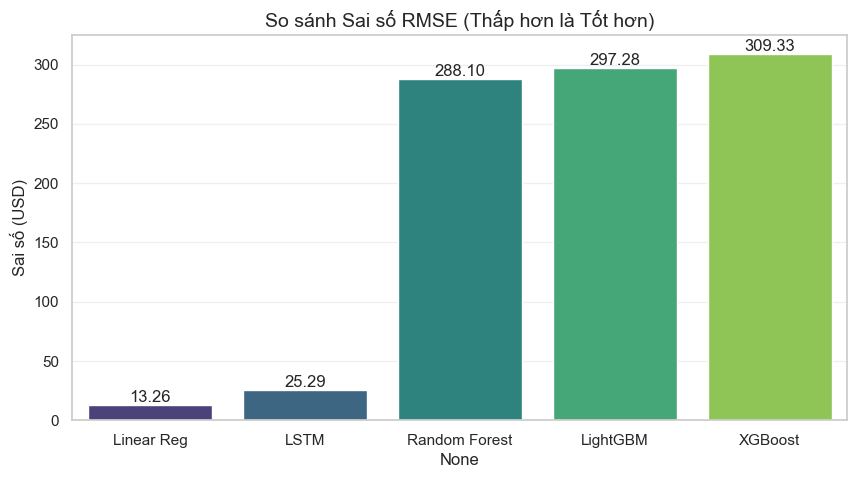

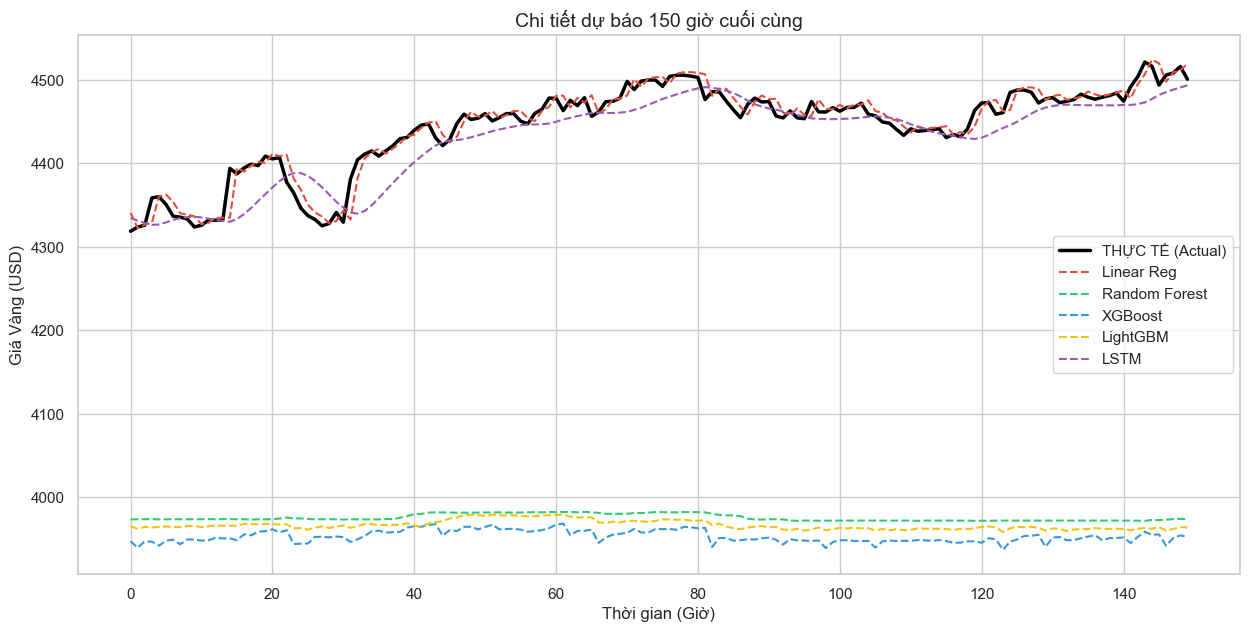

In [19]:
# --- BIỂU ĐỒ 1: SO SÁNH SAI SỐ RMSE ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='viridis')

# Ghi số lên đầu cột cho dễ nhìn
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title('So sánh Sai số RMSE (Thấp hơn là Tốt hơn)', fontsize=14)
plt.ylabel('Sai số (USD)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('../../model/comparison_rmse.png') # Lưu ảnh
plt.show()

# --- BIỂU ĐỒ 2: CUỘC ĐUA DỰ BÁO (Zoom 150 giờ cuối) ---
plt.figure(figsize=(15, 7))

# Vẽ đường thực tế
plt.plot(y_true_usd[-150:], label='THỰC TẾ (Actual)', color='black', linewidth=2.5)

# Vẽ đường dự báo của các model
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f', '#9b59b6'] # Đỏ, Xanh, Lam, Vàng, Tím
for i, (name, pred) in enumerate(preds_usd.items()):
    plt.plot(pred[-150:], label=name, color=colors[i % len(colors)], linestyle='--', linewidth=1.5)

plt.title('Chi tiết dự báo 150 giờ cuối cùng', fontsize=14)
plt.xlabel('Thời gian (Giờ)')
plt.ylabel('Giá Vàng (USD)')
plt.legend()
plt.grid(True)
plt.savefig('../../model/comparison_forecast.png') # Lưu ảnh
plt.show()